Downloading data from kaggle


In [1]:
from google.colab import files
import os

In [2]:
print("Upload files")
uploaded = files.upload()

Upload files


Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
print("Downloading")
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!kaggle datasets download -d kamal01/top-agriculture-crop-disease

Downloading
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [02:22<00:00, 15.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/kamal01/top-agriculture-crop-disease
License(s): CC0-1.0
100% 4.33G/4.33G [05:04<00:00, 15.3MB/s]



In [5]:
!unzip -q plantvillage-dataset.zip -d global_data

In [6]:
!unzip -q top-agriculture-crop-disease.zip -d indian_data

In [7]:
!mkdir -p master_dataset #merge

In [8]:
!cp -r global_data/plantvillage\ dataset/color/* master_dataset/

In [9]:
!cp -r indian_data/Crop\ Diseases/* master_dataset/

Training model

In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

data_dir = 'master_dataset'
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20, zoom_range=0.15, horizontal_flip=True)
train_gen = datagen.flow_from_directory(data_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training')
valid_gen = datagen.flow_from_directory(data_dir, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation')

# Load h5
model = tf.keras.models.load_model('plant_model_pro.h5')

#fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint('plant_model_pro_FINAL.h5', monitor='val_accuracy', save_best_only=True)

history = model.fit(train_gen, validation_data=valid_gen, epochs=10, callbacks=[early_stop, checkpoint])

Found 54120 images belonging to 55 classes.
Found 13509 images belonging to 55 classes.


Epoch 1/10
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9004 - loss: 0.1657

1692/1692 ━━━━━━━━━━━━━━━━━━━━ 1046s 598ms/step - accuracy: 0.9006 - loss: 0.1640 - val_accuracy: 0.8791 - val_loss: 0.2018
Epoch 2/10
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 981s 580ms/step - accuracy: 0.9025 - loss: 0.1566 - val_accuracy: 0.8770 - val_loss: 0.2035
Epoch 3/10
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 974s 575ms/step - accuracy: 0.9044 - loss: 0.1526 - val_accuracy: 0.8787 - val_loss: 0.1997
Epoch 4/10
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 958s 566ms/step - accuracy: 0.9058 - loss: 0.1504 - val_accuracy: 0.8784 - val_loss: 0.2018
Epoch 5/10
1692/1692 ━━━━━━━━━━━━━━━━━━━━ 930s 550ms/step - accuracy: 0.9047 - loss: 0.1491 - val_accuracy: 0.8755 - val_loss: 0.2072


Graph for Accuracy

In [12]:
import matplotlib.pyplot as plt

Accuracy Graph...


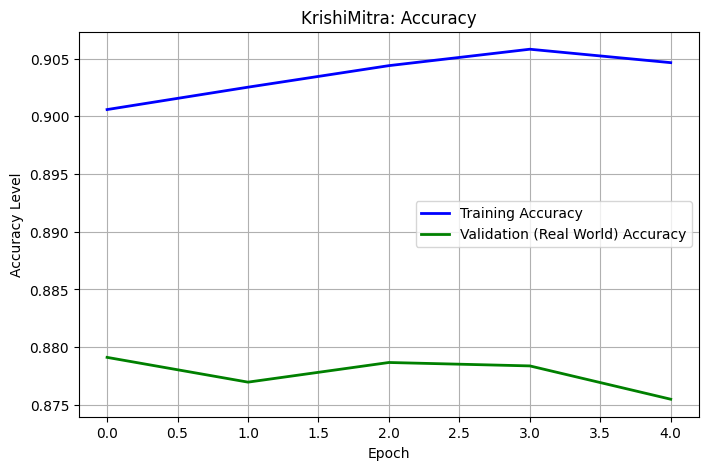

In [15]:
print("Accuracy Graph...")
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation (Real World) Accuracy', color='green', linewidth=2)
plt.title('KrishiMitra: Accuracy')
plt.ylabel('Accuracy Level')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_graph_pro.png')
plt.show()

In [16]:
# for flask app
class_names = list(train_gen.class_indices.keys())
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Corn___Common_Rust', 'Corn___Gray_Leaf_Spot', 'Corn___Healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_Blight', 'Potato___Early_blight', 'Potato___Healthy', 'Potato___Late_Blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Rice___Brown_Spot', 'Rice___Healthy', 'Rice___Leaf_Blast', 'Rice___Neck_Blast', 'Soybean___healthy', 'Squash___Powdery_mildew', 'St

Saving files locally

In [17]:
from google.colab import files

In [19]:
files.download('plant_model_pro_FINAL.h5')
files.download('accuracy_graph_pro.png')

print("Downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded
